In [28]:
import numpy as np

from algorithms.actor_critic.actor_critic_discrete import ACConfig, train_actor_critic
from mdp.cats_v_monsters.cats_vs_monsters import CatsVMonstersMDP


In [ ]:
class CatsVMonstersEnvAdapter:
    """
    Gym-style adapter for CatsVMonstersMDP
    """

    def __init__(self, max_steps: int = 80, start_state=(0, 0)):
        self.mdp = CatsVMonstersMDP()
        self.rows = self.mdp.rows
        self.cols = self.mdp.cols
        self.action_list = self.mdp.get_action_space()
        self.action_space = list(range(len(self.action_list)))
        self.max_steps = max_steps
        self.start_state = start_state

        self.current_state = None
        self.steps = 0

    def state_to_vector(self, state):
        r, c = state
        vec = np.zeros(self.rows * self.cols, dtype=np.float32)
        vec[r * self.cols + c] = 1.0
        return vec

    def reset(self):
        self.current_state = self.start_state
        self.steps = 0
        return self.state_to_vector(self.current_state)

    def step(self, action_idx):
        action_name = self.action_list[action_idx]
        next_state, reward, done = self.mdp.step(self.current_state, action_name)

        self.current_state = next_state
        self.steps += 1

        # enforce episode cutoff
        if self.steps >= self.max_steps:
            done = True

        return self.state_to_vector(next_state), reward, done, {}


def make_cats_env(max_steps: int = 80, start_state=(0, 0)):
    return CatsVMonstersEnvAdapter(max_steps=max_steps, start_state=start_state)


In [ ]:

cfg = ACConfig(
    num_episodes=1200,  # was 400/1000
    max_steps_per_episode=100,  # was 80,90
    gamma=0.99,
    lr=5e-4,  #was 1e-3
    entropy_coef=0.02,  #was 0.01
    hidden_size=64,
    seed=42,
    label="cats_vs_monsters_tuned",
)

env = make_cats_env(max_steps=cfg.max_steps_per_episode, start_state=(0, 0))


In [31]:
# Train the discrete actor-critic agent
result = train_actor_critic(env, cfg, log_interval=25, debug_interval=100)

print("Best reward:", result["best_reward"])
print("Episodes run:", len(result["episode_rewards"]))



Episode 0
Loss: 352.3462
Value Estimate: -0.2056
Policy logits: [[ 0.15038106 -0.07729498  0.04607252 -0.01304672]]
Entropy Mean: 1.3827
Episode Return: -65.80

Episode 25/1200, Return: -66.40, Best so far: 0.95
Episode 50/1200, Return: -98.10, Best so far: 0.95
Episode 75/1200, Return: -92.45, Best so far: 8.95
Episode 100/1200, Return: -76.55, Best so far: 8.95

Episode 100
Loss: 324.1912
Value Estimate: -1.0359
Policy logits: [[ 0.11464444 -0.02001316  0.0671545   0.07562666]]
Entropy Mean: 1.3851
Episode Return: -58.55

Episode 125/1200, Return: -52.70, Best so far: 8.95
Episode 150/1200, Return: 8.90, Best so far: 8.95
Episode 175/1200, Return: -8.35, Best so far: 8.95
Episode 200/1200, Return: -100.40, Best so far: 8.95

Episode 200
Loss: 1180.9348
Value Estimate: -3.8035
Policy logits: [[0.09394766 0.09815939 0.0805678  0.116752  ]]
Entropy Mean: 1.3862
Episode Return: -132.20

Episode 225/1200, Return: -60.65, Best so far: 8.95
Episode 250/1200, Return: -18.35, Best so far: 8.

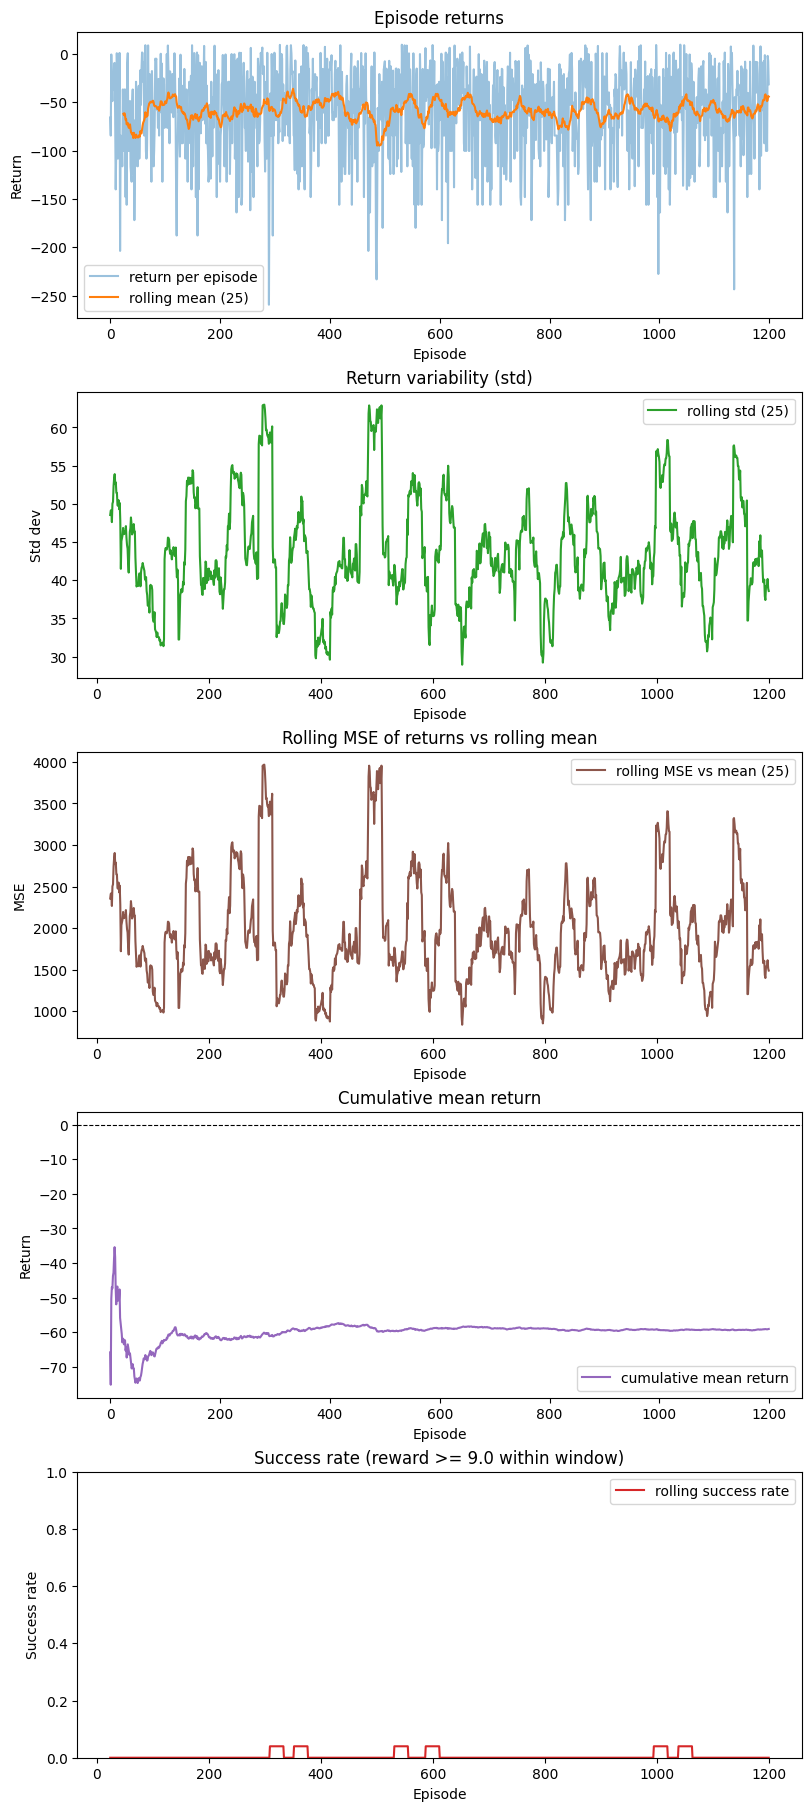

In [7]:
# Reward diagnostics with rolling metrics
try:
    import matplotlib.pyplot as plt
    import numpy as np

    rewards = np.array(result["episode_rewards"], dtype=np.float32)

    window = 25
    if rewards.size < window:
        window = max(1, rewards.size)

    kernel = np.ones(window) / window
    rolling_return = np.convolve(rewards, kernel, mode="valid")

    # Rolling std for variability
    # Use cumulative trick for efficiency
    cumsum = np.cumsum(np.insert(rewards, 0, 0.0))
    cumsum_sq = np.cumsum(np.insert(rewards ** 2, 0, 0.0))
    start = window
    rolling_mean_full = (cumsum[start:] - cumsum[:-start]) / window
    rolling_var_full = (cumsum_sq[start:] - cumsum_sq[:-start]) / window - rolling_mean_full**2
    rolling_std = np.sqrt(np.maximum(rolling_var_full, 0.0))

    # Rolling MSE vs mean is just the variance in that window
    rolling_mse = rolling_var_full
    mse_overall = float(rolling_mse.mean()) if rolling_mse.size else float("nan")

    # Treat reaching the goal as success; reward ≈ +10 minus small step costs
    success_mask = (rewards >= 9.0).astype(np.float32)
    rolling_success = np.convolve(success_mask, kernel, mode="valid")

    cumulative_mean = np.cumsum(rewards) / np.arange(1, rewards.size + 1)

    fig, axes = plt.subplots(5, 1, figsize=(8, 18), constrained_layout=True)

    axes[0].plot(rewards, alpha=0.45, label="return per episode")
    axes[0].plot(
        range(window - 1, window - 1 + rolling_return.size),
        rolling_return,
        label=f"rolling mean ({window})",
        color="C1",
    )
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Return")
    axes[0].set_title("Episode returns")
    axes[0].legend()

    axes[1].plot(
        range(window - 1, window - 1 + rolling_std.size),
        rolling_std,
        label=f"rolling std ({window})",
        color="C2",
    )
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Std dev")
    axes[1].set_title("Return variability (std)")
    axes[1].legend()

    axes[2].plot(
        range(window - 1, window - 1 + rolling_mse.size),
        rolling_mse,
        label=f"rolling MSE vs mean ({window})",
        color="C5",
    )
    axes[2].set_xlabel("Episode")
    axes[2].set_ylabel("MSE")
    axes[2].set_title("Return volatility (rolling MSE vs mean)")
    axes[2].legend()

    axes[3].plot(cumulative_mean, label="cumulative mean return", color="C4")
    axes[3].axhline(0, color="k", lw=0.8, ls="--")
    axes[3].set_xlabel("Episode")
    axes[3].set_ylabel("Return")
    axes[3].set_title("Cumulative mean return")
    axes[3].legend()

    axes[4].plot(
        range(window - 1, window - 1 + rolling_success.size),
        rolling_success,
        label="rolling success rate",
        color="C3",
    )
    axes[4].set_ylim(0, 1)
    axes[4].set_xlabel("Episode")
    axes[4].set_ylabel("Success rate")
    axes[4].set_title("Success rate (reward >= 9.0 within window)")
    axes[4].legend()

    plt.show()
except Exception as exc:  # noqa: BLE001
    print(f"Plotting skipped: {exc}")
